# Step 02 — BGG Data EDA

Exploratory analysis of `games_detailed_info2025.csv` (~28k games) and `bgg-26m-reviews.csv` (~26M ratings).

**Outputs:** `games_features.parquet`, `ratings_implicit.parquet` (via `scripts/preprocess_to_parquet.py`)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

from bgg.config import settings
from bgg.preprocessing.games import build_games_features, load_games_csv
from bgg.preprocessing.ratings import load_reviews_csv
from bgg.preprocessing.spark import build_spark

RAW_DIR = settings.raw_dir
PROCESSED_DIR = settings.processed_dir
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Uses 1g driver memory + Windows Hadoop/PYSPARK fixes (see preprocessing/spark.py).
# 32-bit Java cannot allocate 4g — do not raise spark.driver.memory in the notebook.
spark = build_spark("bgg-eda")
spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version}")
print(f"Project raw dir: {RAW_DIR.resolve()}")
print(f"Games CSV exists: {(RAW_DIR / 'games_detailed_info2025.csv').exists()}")

Spark 3.5.8
Project raw dir: C:\Users\josec\Desktop\projects\bgg\data\raw
Games CSV exists: True


## 1. Load & profile raw data

In [2]:
games_raw = load_games_csv(spark, RAW_DIR)
reviews_raw = load_reviews_csv(spark, RAW_DIR)

print("=== Games schema ===")
games_raw.printSchema()
games_count = games_raw.count()
print(f"Games rows: {games_count:,}")

key_cols = ["id", "name", "bayesaverage", "boardgamemechanic", "minplayers", "maxplayers"]
print("\nGames null/blank counts:")
for col in key_cols:
    nulls = games_raw.filter(F.col(col).isNull() | (F.length(F.trim(col)) == 0)).count()
    print(f"  {col}: {nulls:,}")

print("\n=== Reviews (user, rating, ID only) ===")
reviews_raw.printSchema()
reviews_count = reviews_raw.count()
distinct_users = reviews_raw.select("user").distinct().count()
distinct_review_games = reviews_raw.select("ID").distinct().count()
print(f"Reviews rows: {reviews_count:,}")
print(f"Distinct users: {distinct_users:,}")
print(f"Distinct game IDs: {distinct_review_games:,}")

=== Games schema ===
root
 |-- _c0: string (nullable = true)
 |-- type: string (nullable = true)
 |-- id: string (nullable = true)
 |-- thumbnail: string (nullable = true)
 |-- image: string (nullable = true)
 |-- alternate: string (nullable = true)
 |-- description: string (nullable = true)
 |-- yearpublished: string (nullable = true)
 |-- minplayers: string (nullable = true)
 |-- maxplayers: string (nullable = true)
 |-- suggested_num_players: string (nullable = true)
 |-- suggested_playerage: string (nullable = true)
 |-- suggested_language_dependence: string (nullable = true)
 |-- playingtime: string (nullable = true)
 |-- minplaytime: string (nullable = true)
 |-- maxplaytime: string (nullable = true)
 |-- minage: string (nullable = true)
 |-- boardgamecategory: string (nullable = true)
 |-- boardgamemechanic: string (nullable = true)
 |-- boardgamefamily: string (nullable = true)
 |-- boardgameexpansion: string (nullable = true)
 |-- boardgameaccessory: string (nullable = true)
 

## 2. Games EDA

In [3]:
games_features = build_games_features(games_raw)
print(f"Clean games: {games_features.count():,}")
games_features.select(
    "min_players", "max_players", "playing_time", "bayes_average", "avg_weight"
).summary().show()

Clean games: 24,188
+-------+------------------+-----------------+-----------------+------------------+------------------+
|summary|       min_players|      max_players|     playing_time|     bayes_average|        avg_weight|
+-------+------------------+-----------------+-----------------+------------------+------------------+
|  count|             24188|            24188|            24004|             23535|             23826|
|   mean|1.9658508351248554| 4.82702166363486|92.94905015830695| 5.928298945825365|31.834260351296898|
| stddev|0.8050516691051679|3.042920454417248|631.1245763844753|18.835576236694155| 882.7224814504856|
|    min|                 1|                1|                0|               0.0|               0.0|
|    25%|                 2|                4|               30|           5.51012|            1.3333|
|    50%|                 2|                4|               45|           5.53806|            1.9388|
|    75%|                 2|                6|       

In [4]:
top_games = (
    games_features.select("game_id", "name", "bayes_average", "num_ratings")
    .orderBy(F.col("bayes_average").desc_nulls_last())
    .limit(20)
)
top_games.show(truncate=False)

+-------+--------------------------------------------------------------------+-------------+-----------+
|game_id|name                                                                |bayes_average|num_ratings|
+-------+--------------------------------------------------------------------+-------------+-----------+
|2386   |'Brybelly'                                                          |1893.0       |NULL       |
|138233 |'Ascension: Gift of the Elements'                                   |1801.0       |NULL       |
|144864 |'Ascension: Immortal Heroes'                                        |1038.0       |NULL       |
|241225 |'Smash Up: Science Fiction Double Feature'                          |508.0        |NULL       |
|1421   |'Lost Worlds: ""Eilee"" the Sprite'                                 |452.0        |NULL       |
|121921 |'Robinson Crusoe: Adventures on the Cursed Island – Gamer Character'|120.0        |120        |
|7723   |4                                             

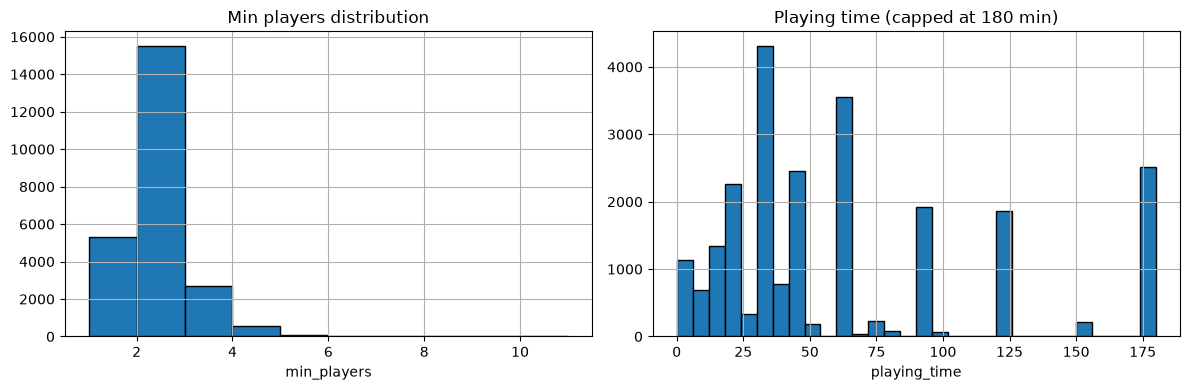

In [5]:
player_pdf = games_features.select("min_players").toPandas()
time_pdf = games_features.select("playing_time").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
player_pdf["min_players"].hist(bins=range(1, 12), ax=axes[0], edgecolor="black")
axes[0].set_title("Min players distribution")
axes[0].set_xlabel("min_players")
time_pdf["playing_time"].clip(upper=180).hist(bins=30, ax=axes[1], edgecolor="black")
axes[1].set_title("Playing time (capped at 180 min)")
axes[1].set_xlabel("playing_time")
plt.tight_layout()
plt.show()

## 3. Mechanics & categories

In [6]:
mechanics_top = (
    games_features.select(F.explode("mechanics").alias("mechanic"))
    .groupBy("mechanic")
    .count()
    .orderBy(F.col("count").desc())
    .limit(30)
)
mechanics_top.show(truncate=False)

coop_count = games_features.filter(F.col("is_cooperative")).count()
print(f"Cooperative games (mechanic tag): {coop_count:,}")

+-----------------------------+-----+
|mechanic                     |count|
+-----------------------------+-----+
|Dice Rolling                 |6505 |
|Hand Management              |5081 |
|Set Collection               |3276 |
|Variable Player Powers       |3024 |
|Hexagon Grid                 |2630 |
|Simulation                   |2281 |
|Open Drafting                |2247 |
|Tile Placement               |2111 |
|Cooperative Game             |2010 |
|Grid Movement                |1870 |
|Modular Board                |1789 |
|Area Majority / Influence    |1785 |
|Solo / Solitaire Game        |1689 |
|Take That                    |1433 |
|Action Points                |1320 |
|Area Movement                |1292 |
|Simultaneous Action Selection|1290 |
|Auction / Bidding            |1163 |
|Push Your Luck               |1127 |
|Team-Based Game              |1126 |
+-----------------------------+-----+
only showing top 20 rows

Cooperative games (mechanic tag): 2,010


## 4. Ratings sparsity (26M rows)

In [7]:
catalog_game_ids = games_features.select(F.col("game_id").alias("ID"))
reviews_in_catalog = reviews_raw.join(catalog_game_ids, on="ID", how="inner")
catalog_review_count = reviews_in_catalog.count()
catalog_users = reviews_in_catalog.select("user").distinct().count()
catalog_games = reviews_in_catalog.select("ID").distinct().count()

sparsity_all = 1 - (reviews_count / (distinct_users * distinct_review_games))
sparsity_catalog = 1 - (catalog_review_count / (catalog_users * catalog_games))

print(f"All reviews sparsity: {sparsity_all:.4%}")
print(f"Catalog-intersect sparsity: {sparsity_catalog:.4%}")
print(f"Reviews in 28k catalog: {catalog_review_count:,} ({catalog_review_count/reviews_count:.1%} of raw)")

All reviews sparsity: 99.9732%
Catalog-intersect sparsity: 99.8350%
Reviews in 28k catalog: 21,314,764 (81.4% of raw)


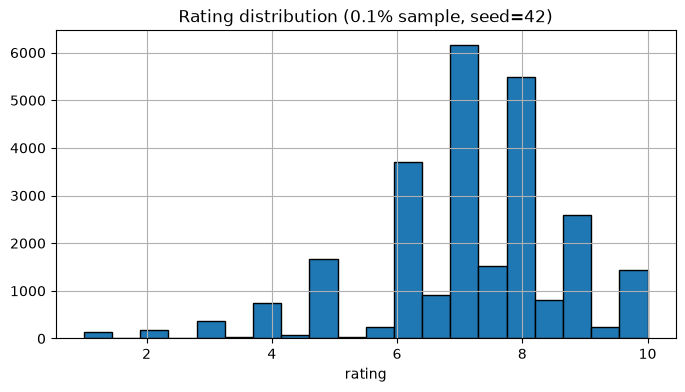

In [8]:
rating_sample = reviews_raw.sample(fraction=0.001, seed=42).select("rating").toPandas()
rating_sample["rating"] = pd.to_numeric(rating_sample["rating"], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 4))
rating_sample["rating"].dropna().hist(bins=20, ax=ax, edgecolor="black")
ax.set_title("Rating distribution (0.1% sample, seed=42)")
ax.set_xlabel("rating")
plt.show()

## 5. Two-player slice (primary use case)

In [9]:
two_player = games_features.filter(
    (F.col("min_players") <= 2) & (F.col("max_players") >= 2)
)
two_player_count = two_player.count()
avg_time = two_player.agg(F.avg("playing_time").alias("avg_playing_time")).collect()[0][0]
print(f"2-player capable games: {two_player_count:,} ({two_player_count/games_features.count():.1%})")
print(f"Average playing time (2p slice): {avg_time:.1f} min")

2-player capable games: 19,960 (82.5%)
Average playing time (2p slice): 98.4 min


## 6. Export & validate

Production export is handled by `python scripts/preprocess_to_parquet.py`. Re-run validation here after export.

In [10]:
import pyarrow.parquet as pq

games_pq = pq.read_table(PROCESSED_DIR / "games_features.parquet").to_pandas()
ratings_pq = pq.read_table(PROCESSED_DIR / "ratings_implicit.parquet").to_pandas()

assert len(games_pq) >= 20_000
assert len(games_pq[(games_pq["min_players"] <= 2) & (games_pq["max_players"] >= 2)]) > 0
assert ratings_pq["game_id"].nunique() > 1_000
assert len(ratings_pq) > 0

print("Validation passed.")
print(games_pq[["game_id", "name", "min_players", "max_players", "bayes_average"]].head())
print(ratings_pq.head())

Validation passed.
   game_id                                    name  min_players  max_players  \
0       13  'De Kolonisten van Catan: De Koloniën'            3            4   
1      822                             Carcassonne            2            5   
2    30549                                Pandemic            2            4   
3    68448                               7 Wonders            2            7   
4   167791                                 8.35266            1            5   

   bayes_average  
0            NaN  
1        7.29556  
2        7.42156  
3        7.56393  
4            NaN  
               user_id  game_id  rating  implicit_strength
0  -750893617188448676       13    10.0                1.0
1 -8273093403456906930       13    10.0                1.0
2 -6197808622742796213       13    10.0                1.0
3  4908433980040042602       13    10.0                1.0
4  1311389892730527250       13    10.0                1.0


## 7. Conclusions (for Step 03 recommender)

- **Sparsity > 99%** even after catalog join — pure collaborative filtering is unreliable for cold users; hybrid ALS + content is justified.
- **~23k games** support 2 players — session filter `min_players <= 2 <= max_players` is viable but shrinks the candidate pool.
- **Cooperative flag** via `"Cooperative Game"` mechanic supports `mode=cooperative` filter in Step 03.
- **Mechanics/categories** are human-readable lists — suitable for CountVectorizer in content-based filtering.
- **26M reviews** filtered to catalog game IDs still yield millions of edges for ALS training.
- **Cold start:** users with < 3 liked games should use content + popularity fallback (see pitfalls doc).